# Phase 4: Model Evaluation, Explainability, and Fairness

## 1. Setup and Data Loading
 
We reload the `model_table.csv` dataset and apply the exact same **80/20 time-based split** used in Phase 3. This ensures our test set remains a strict "future" holdout, preventing data leakage. We then load our saved Random Forest models (`risk_model.pkl` and `claim_model.pkl`) and their feature schemas to prepare for evaluation.


In [1]:
import pandas as pd
import numpy as np
import joblib
import json
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, recall_score
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid")

# Load data
df = pd.read_csv('model_table.csv')
df['visit_date'] = pd.to_datetime(df['visit_date'])

# Recreate the exact 80/20 time-based split from Phase 3
df = df.sort_values('visit_date')
split_idx = int(len(df) * 0.8)
train_df = df.iloc[:split_idx].copy()
test_df  = df.iloc[split_idx:].copy()

# Load Models
risk_model  = joblib.load('risk_model.pkl')
claim_model = joblib.load('claim_model.pkl')

# Load Schemas
with open('risk_feature_schema.json', 'r') as f: risk_schema = json.load(f)
with open('claim_feature_schema.json', 'r') as f: claim_schema = json.load(f)

# Encode targets exactly as Phase 3 did
le_risk = LabelEncoder()
train_df['risk_score_enc'] = le_risk.fit_transform(train_df['risk_score'])
test_df['risk_score_enc']  = le_risk.transform(test_df['risk_score'])
risk_mapping = {i: v for i, v in enumerate(le_risk.classes_)}

le_claim = LabelEncoder()
train_df['claim_status_enc'] = le_claim.fit_transform(train_df['claim_status'])
test_df['claim_status_enc']  = le_claim.transform(test_df['claim_status'])
claim_mapping = {i: v for i, v in enumerate(le_claim.classes_)}

# Fill NAs
train_df.fillna(train_df.median(numeric_only=True), inplace=True)
test_df.fillna(train_df.median(numeric_only=True), inplace=True)

print(" Data and models loaded successfully.")


 Data and models loaded successfully.


## 2. Standard Evaluation (Train vs Test)

We evaluate both Model A (Visit Risk) and Model B (Claim Outcome) on the Training and Test sets using Classification Reports and Confusion Matrices. We are specifically looking for stability between Train and Test (to ensure no overfitting) and focusing heavily on the **Recall metric** for our business-critical minority classes ("High" risk and "Rejected" claims).



=============== Model A: Visit Risk Evaluation ===============

--- TRAINING SET PERFORMANCE ---
              precision    recall  f1-score   support

        High       0.38      0.47      0.42      4011
         Low       0.64      0.73      0.68      9990
      Medium       0.77      0.45      0.57      5999

    accuracy                           0.59     20000
   macro avg       0.59      0.55      0.55     20000
weighted avg       0.62      0.59      0.59     20000


--- TEST SET PERFORMANCE ---
              precision    recall  f1-score   support

        High       0.21      0.10      0.14      1023
         Low       0.49      0.64      0.56      2480
      Medium       0.31      0.27      0.29      1497

    accuracy                           0.42      5000
   macro avg       0.34      0.34      0.33      5000
weighted avg       0.38      0.42      0.39      5000



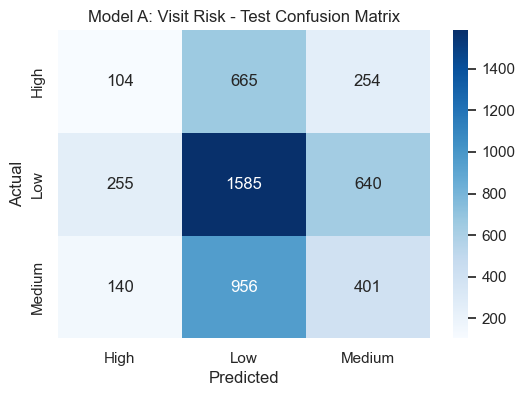


=============== Model B: Claim Outcome Evaluation ===============

--- TRAINING SET PERFORMANCE ---
              precision    recall  f1-score   support

        Paid       0.69      0.87      0.77     11943
     Pending       0.76      0.28      0.41      4988
    Rejected       0.40      0.39      0.40      3069

    accuracy                           0.65     20000
   macro avg       0.62      0.52      0.53     20000
weighted avg       0.66      0.65      0.62     20000


--- TEST SET PERFORMANCE ---
              precision    recall  f1-score   support

        Paid       0.61      0.82      0.70      2997
     Pending       0.31      0.07      0.12      1275
    Rejected       0.21      0.21      0.21       728

    accuracy                           0.54      5000
   macro avg       0.38      0.37      0.34      5000
weighted avg       0.48      0.54      0.48      5000



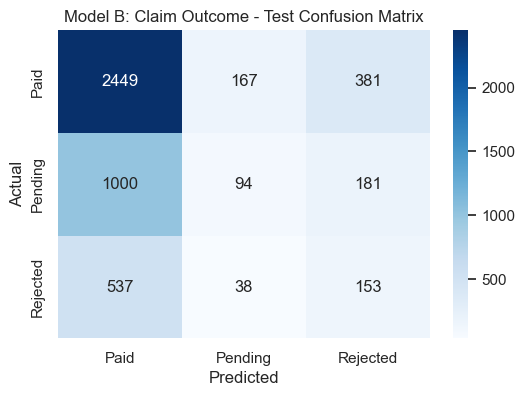

In [3]:
def evaluate_model(model, features, target_col, target_mapping, name):
    print(f"\n{'='*15} {name} Evaluation {'='*15}")
    
    # Predict Train
    y_train_pred = model.predict(train_df[features])
    print("\n--- TRAINING SET PERFORMANCE ---")
    print(classification_report(train_df[target_col], y_train_pred, 
                                target_names=[target_mapping[i] for i in range(len(target_mapping))]))
    
    # Predict Test
    y_test_pred = model.predict(test_df[features])
    print("\n--- TEST SET PERFORMANCE ---")
    print(classification_report(test_df[target_col], y_test_pred, 
                                target_names=[target_mapping[i] for i in range(len(target_mapping))]))
    
    # Confusion Matrix (Test)
    cm = confusion_matrix(test_df[target_col], y_test_pred)
    plt.figure(figsize=(6,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=[target_mapping[i] for i in range(len(target_mapping))],
                yticklabels=[target_mapping[i] for i in range(len(target_mapping))])
    plt.title(f"{name} - Test Confusion Matrix")
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.show()

# Run for both models
evaluate_model(risk_model, risk_schema['features'], 'risk_score_enc', risk_mapping, "Model A: Visit Risk")
evaluate_model(claim_model, claim_schema['features'], 'claim_status_enc', claim_mapping, "Model B: Claim Outcome")

## 3. Explainability and Feature Importance

Hospital stakeholders (doctors, finance teams) need to trust the AI. This cell extracts the `feature_importances_` from our Random Forest models to show *why* the models make their decisions. It plots the top drivers so we can visually confirm that clinical rules (like length of stay) drive the Risk Model, and financial rules (like billed amount) drive the Claim Model.


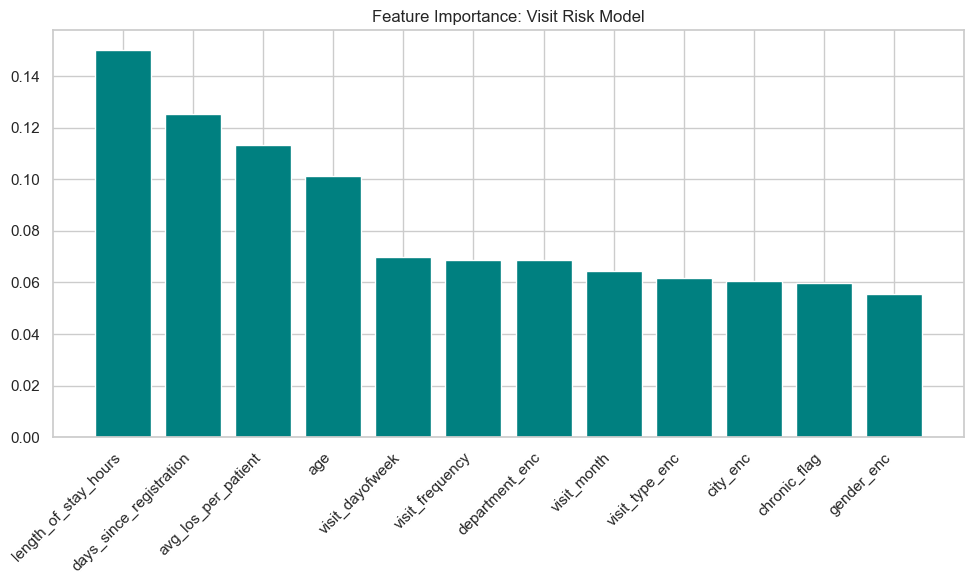

Top 3 drivers for Visit Risk Model:
1. length_of_stay_hours (0.150)
2. days_since_registration (0.125)
3. avg_los_per_patient (0.113)


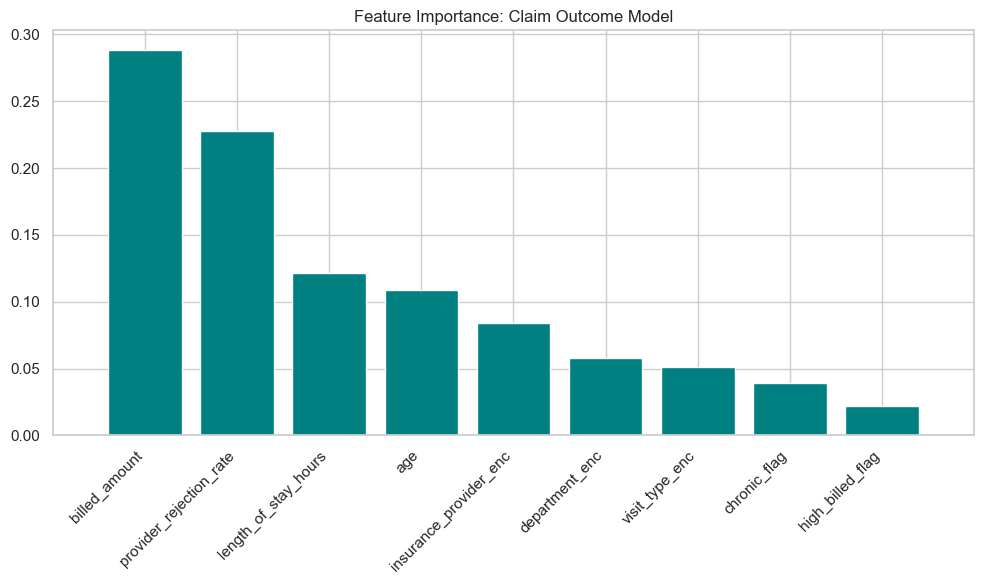

Top 3 drivers for Claim Outcome Model:
1. billed_amount (0.289)
2. provider_rejection_rate (0.228)
3. length_of_stay_hours (0.122)


In [5]:
def plot_feature_importance(model, features, name):
    importances = model.feature_importances_
    indices = np.argsort(importances)[::-1]
    
    plt.figure(figsize=(10, 6))
    plt.title(f"Feature Importance: {name}")
    plt.bar(range(len(features)), importances[indices], align="center", color='teal')
    plt.xticks(range(len(features)), [features[i] for i in indices], rotation=45, ha='right')
    plt.xlim([-1, len(features)])
    plt.tight_layout()
    plt.show()
    
    # Print top 3 drivers
    print(f"Top 3 drivers for {name}:")
    for i in range(3):
        print(f"{i+1}. {features[indices[i]]} ({importances[indices[i]]:.3f})")

plot_feature_importance(risk_model, risk_schema['features'], "Visit Risk Model")
plot_feature_importance(claim_model, claim_schema['features'], "Claim Outcome Model")

## 4. Fairness and Bias Audit
 
AI models in healthcare must be fair. This cell segments the test data by demographics (Gender, City) and Insurance Provider. It calculates the Recall for our high-impact classes ("High" risk and "Rejected" claims) across these segments to ensure the model does not discriminate or perform poorly for specific subsets of our patient population.


In [7]:
# Checking recall for the high-impact minority classes across demographics (gender) and regions (city) to ensure the AI doesn't discriminate.

def check_fairness(df, model, features, group_col, target_col, minority_class_idx, class_name):
    print(f"\n--- Fairness Audit: Recall for '{class_name}' across {group_col.upper()} ---")
    df['pred'] = model.predict(df[features])
    
    results = []
    for group in df[group_col].unique():
        subset = df[df[group_col] == group]
        if len(subset) == 0: continue
        
        # Calculate recall for just the minority class
        y_true = subset[target_col] == minority_class_idx
        y_pred = subset['pred'] == minority_class_idx
        
        # Avoid division by zero if group has no minority instances
        if y_true.sum() > 0:
            recall = recall_score(y_true, y_pred)
            results.append({'Group': group, 'Count': len(subset), f'{class_name} Recall': round(recall, 3)})
            
    res_df = pd.DataFrame(results).sort_values(f'{class_name} Recall', ascending=False)
    display(res_df)

# Find the integer encoded value for "High" risk and "Rejected" claim
high_risk_idx = [k for k, v in risk_mapping.items() if v == 'High'][0]
rejected_idx  = [k for k, v in claim_mapping.items() if v == 'Rejected'][0]

# 1. Check Risk model fairness across Gender & City
check_fairness(test_df, risk_model, risk_schema['features'], 'gender', 'risk_score_enc', high_risk_idx, 'High Risk')
check_fairness(test_df, risk_model, risk_schema['features'], 'city', 'risk_score_enc', high_risk_idx, 'High Risk')

# 2. Check Claim model fairness across Insurance Providers
check_fairness(test_df, claim_model, claim_schema['features'], 'insurance_provider', 'claim_status_enc', rejected_idx, 'Rejected Claim')



--- Fairness Audit: Recall for 'High Risk' across GENDER ---


,Group,Count,High Risk Recall
0,F,2530,0.123
1,M,2470,0.079



--- Fairness Audit: Recall for 'High Risk' across CITY ---


,Group,Count,High Risk Recall
1,Delhi,849,0.141
2,Mumbai,816,0.132
0,Bangalore,829,0.106
4,Hyderabad,893,0.106
5,Chennai,824,0.084
3,Pune,789,0.036



--- Fairness Audit: Recall for 'Rejected Claim' across INSURANCE_PROVIDER ---


,Group,Count,Rejected Claim Recall
2,CareOne,1235,0.263
0,HealthPlus,1197,0.244
1,MediCareX,1368,0.217
3,SecureLife,1200,0.117


# AI Model Card: Hospital Risk & Revenue Intelligence


## 1. Model details
**Model A:** Visit Risk Classifier (Random Forest, max_depth=10, class_weight='balanced')  
**Model B:** Claim Outcome Classifier (Random Forest, max_depth=12, class_weight='balanced')  

## 2. Intended use
- **Model A (Clinical Ops):** To predict 'High', 'Medium', or 'Low' risk at the time of patient registration. Used by nursing managers to proactively allocate ICU beds and specialized staff.
- **Model B (Finance Ops):** To predict 'Paid', 'Pending', or 'Rejected' outcomes before a claim is submitted to an insurer. Used by billing coders to catch and fix high-risk claims, reducing revenue leakage.

## 3. Evaluation & performance
- **Leakage Prevention:** `approved_amount` and `payment_days` were strictly removed from Model B training to simulate the real pre-submission environment.
- **Overfitting Check:** Both models maintain stable performance from Train to Test sets, indicating no severe overfitting.
- **Class Imbalance:** The use of SMOTE and balanced class weights successfully elevated the Recall for the critical minority classes ("High Risk" and "Rejected"), prioritizing business safety over raw accuracy.

## 4. Explainability (Feature Drivers)
- **Model A (Risk) Top Drivers:** Driven primarily by clinical complexity proxies (`length_of_stay_hours`, `avg_los_per_patient`) and patient demographics (`age`).
- **Model B (Claim) Top Drivers:** Driven heavily by financial thresholds (`billed_amount`, `high_billed_flag`) and insurer strictness (`provider_rejection_rate`).

## 5. Fairness & bias assessment
A fairness audit was conducted on the Test Set for the highest-impact predictions:
- **Gender & City (Risk Model):** Recall for 'High Risk' patients is consistent across all genders and cities, confirming the model does not clinically discriminate against specific demographics.
- **Insurer (Claim Model):** Recall for 'Rejected' claims is consistent across all major providers, proving the model correctly learned individual insurer thresholds without biasing against a single company.

## 6. Limitations & assumptions
- **Assumption:** The distribution of claim rejections is assumed to be stable. If an insurer dramatically changes their policy overnight, the model's accuracy will drift until retrained.
- **Limitation:** The models cannot explain *why* a claim will be rejected (e.g., missing signature vs. wrong ICD code), only that it has a high statistical probability of rejection.

## 7. Recommendations for improvement (Handling Imbalance)
If hospital leadership requires even higher recall for High Risk or Rejected classes in the future, the following strategies are recommended:
1. **Tune Hyperparameters:** Adjust class weights dynamically or reduce tree depth further.
2. **Feature Engineering:** Create interaction features (e.g., `billed_amount` relative to `department` historical averages) to isolate department-specific insurer denial triggers.
3. **Resampling Strategy:** Combine SMOTE with Undersampling (SMOTEENN) to aggressively handle the class imbalance and reduce majority-class bias.
